# Behavioural Analysis for Project Defaulter Early Flagging

In [8]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
# Configure the output directories
plots_dir = '/kaggle/working/plots'
files_dir = '/kaggle/working/data'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(files_dir, exist_ok=True)

def save_plot(filename):
    plots_dir = '/kaggle/working/plots'
    os.makedirs(plots_dir, exist_ok=True)

    full_path = os.path.join(plots_dir, filename)
    plt.savefig(full_path, bbox_inches='tight', dpi=300)
    print(f"{filename} saved to: {full_path}")


def save_csv(frame, filename):
    files_dir = '/kaggle/working/data'
    os.makedirs(files_dir, exist_ok=True)

    full_path = os.path.join(files_dir, filename)
    frame.to_csv(full_path, index=False)
    print(f"{filename} saved to: {full_path}")

In [10]:
# Load the dataset (low_memory=false, since it was reading a columntype wrong in an attempt without it.)
dft = pd.read_csv('/kaggle/input/datasets/parasharmanu/the-berka-wrangled/transactions.csv', low_memory=False)
dfl = pd.read_csv('/kaggle/input/datasets/parasharmanu/the-berka-wrangled/loans.csv', low_memory=False)

In [11]:
# Configuring datetime values
dft['date'] = pd.to_datetime(dft['date'])
dfl['start_date'] = pd.to_datetime(dfl['start_date'])
dfl['end_date'] = pd.to_datetime(dfl['end_date'])

defaulter
0    606
1     76
Name: count, dtype: int64
defaulter
0    88.856305
1    11.143695
Name: proportion, dtype: float64
class_imbalance.png saved to: /kaggle/working/plots/class_imbalance.png


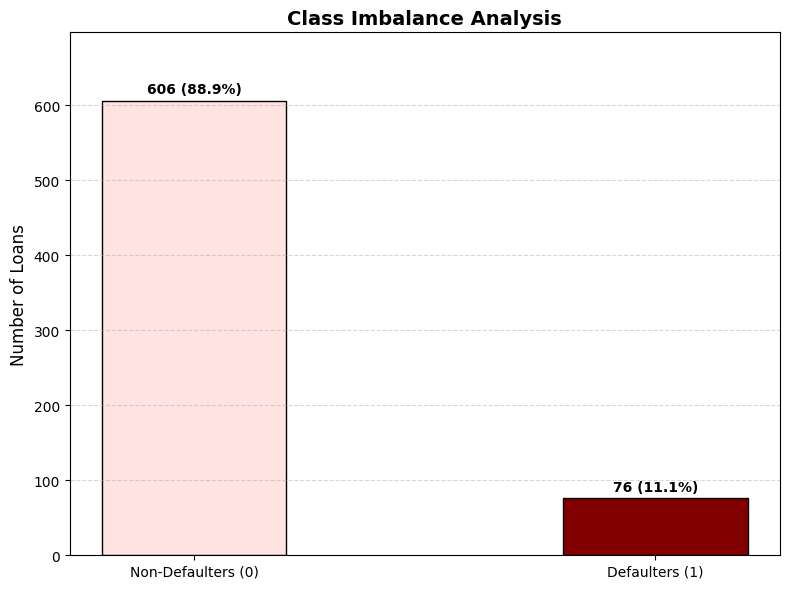

In [12]:
# State the class imbalance
print(dfl['defaulter'].value_counts())
print(dfl['defaulter'].value_counts(normalize=True) * 100)
counts = dfl["defaulter"].value_counts()
percentages = dfl["defaulter"].value_counts(normalize=True) * 100
labels = ["Non-Defaulters (0)", "Defaulters (1)"]
values = [counts.get(0, 0), counts.get(1, 0)]
pct_values = [percentages.get(0, 0), percentages.get(1, 0)]
plt.figure(figsize=(8, 6))
bars = plt.bar(
    labels,
    values,
    color=["mistyrose", "maroon"],
    edgecolor="black",
    width=0.4,
)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(values) * 0.01),
        f"{int(height):,} ({pct_values[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )
plt.title(
    "Class Imbalance Analysis",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Number of Loans", fontsize=12)
plt.ylim(0, max(values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
save_plot('class_imbalance.png')
plt.tight_layout()
plt.show()

> ##### *A significant class imbalance, but resembling the real-world scenerio. Must be stated before any analysis.*

loans_per_account.png saved to: /kaggle/working/plots/loans_per_account.png


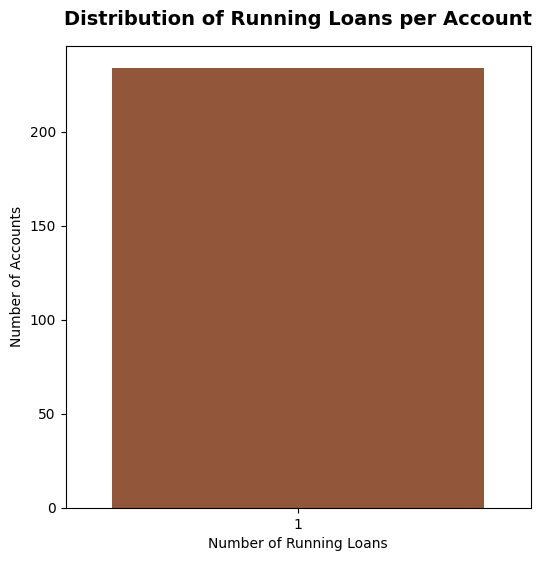

In [13]:
# Find the number of Loans per account
dfl_running = dfl[dfl['running'] == 1]
loan_count = (
    dfl_running.groupby('account_id').size().reset_index(name='running_loan_count')
)
plt.figure(figsize=(6,6))

sns.countplot(
    data=loan_count,
    x='running_loan_count',
    color='sienna'
)

plt.title('Distribution of Running Loans per Account', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Running Loans')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
save_plot('loans_per_account.png')
plt.show()

> ##### *Confirmed that no account has more than one running loan.*

duration_vs_default.png saved to: /kaggle/working/plots/duration_vs_default.png


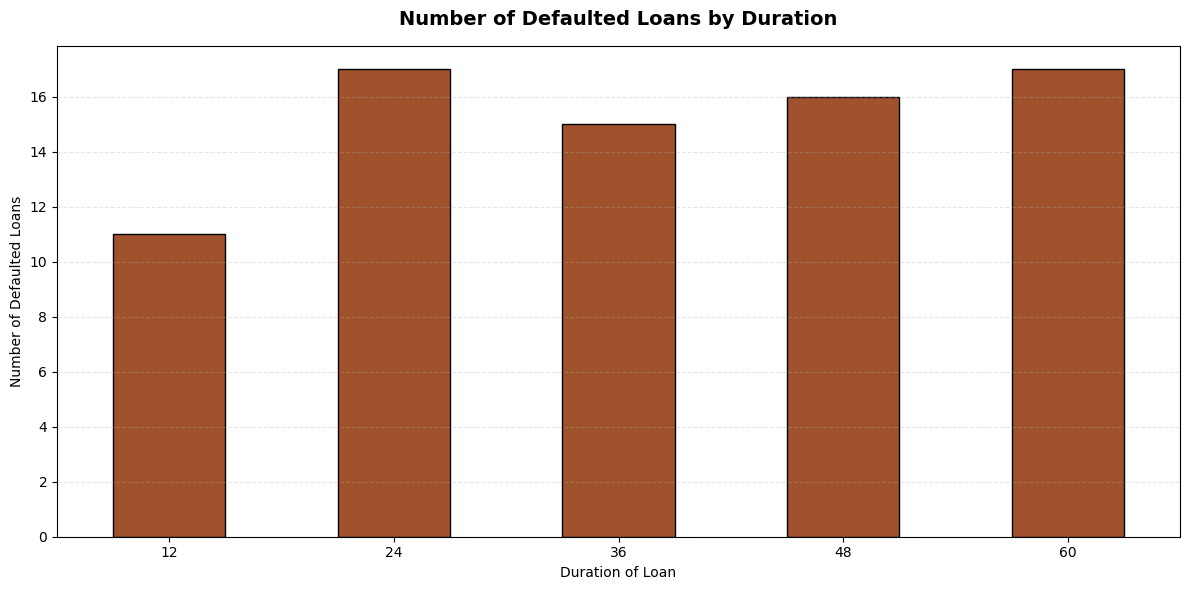

In [14]:
# Bivariate relationship between number of default loans and loan duration
plt.figure(figsize=(12,6))
defaulted_dfl = dfl[dfl['defaulter'] == 1]
duration_counts = defaulted_dfl['duration'].value_counts().sort_index()
duration_counts.plot(kind='bar', color='sienna', edgecolor='black')

plt.title('Number of Defaulted Loans by Duration', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Duration of Loan')
plt.ylabel('Number of Defaulted Loans')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
save_plot('duration_vs_default.png')
plt.show()

> ##### *No specific pattern observed. Duration of loan holds very less weight in deciding whether it'll be defaulted or not.*

amount_vs_default.png saved to: /kaggle/working/plots/amount_vs_default.png


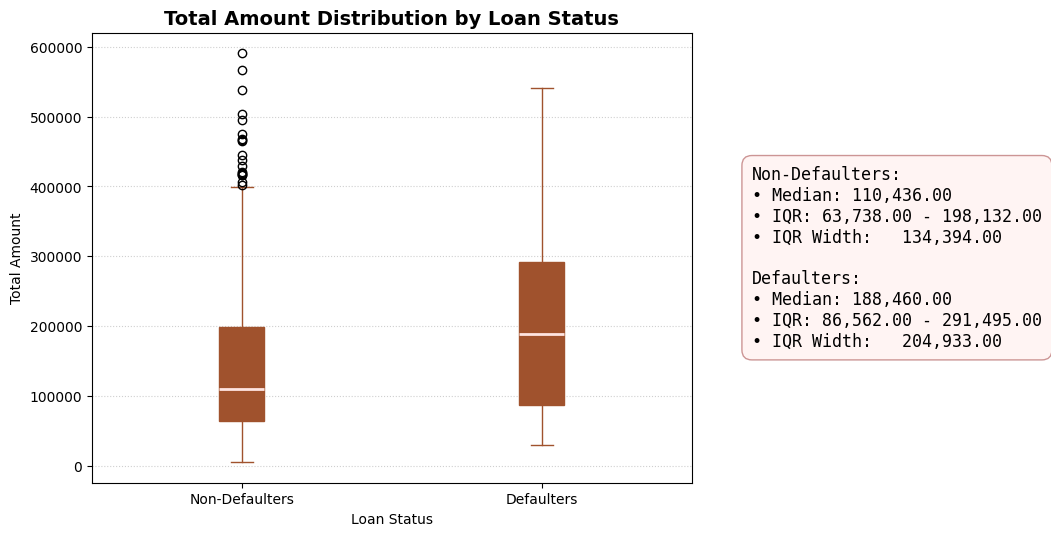

In [15]:
# Lend amount distribution among loan defaulters and non-defaulters
summary = dfl.groupby('defaulter')['total_amount'].describe()
iqr_0 = summary.loc[0, '75%'] - summary.loc[0, '25%']
iqr_1 = summary.loc[1, '75%'] - summary.loc[1, '25%']

insights_text = (
    'Non-Defaulters:\n'
    f'• Median: {summary.loc[0, '50%']:,.2f}\n'
    f'• IQR: {summary.loc[0, '25%']:,.2f} - {summary.loc[0, '75%']:,.2f}\n'
    f'• IQR Width:   {iqr_0:,.2f}\n\n'
    'Defaulters:\n'
    f'• Median: {summary.loc[1, '50%']:,.2f}\n'
    f'• IQR: {summary.loc[1, '25%']:,.2f} - {summary.loc[1, '75%']:,.2f}\n'
    f'• IQR Width:   {iqr_1:,.2f}'
)

fig, ax = plt.subplots(figsize=(12, 6))

dfl.boxplot(column='total_amount', by='defaulter', grid=False, patch_artist=True, 
            color='sienna', medianprops={'color': 'mistyrose', 'linewidth': 2}, ax=ax)

plt.title('Total Amount Distribution by Loan Status', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Total Amount')
plt.xticks([1, 2], ['Non-Defaulters', 'Defaulters'])
plt.grid(axis='y', linestyle=':', alpha=0.6)

box_style = dict(boxstyle='round,pad=0.6', facecolor='mistyrose', edgecolor='maroon', alpha=0.4)
ax.text(1.1, 0.5, insights_text, transform=ax.transAxes, fontsize=12, fontfamily='monospace',
        verticalalignment='center', horizontalalignment='left', bbox=box_style)
plt.subplots_adjust(right=0.60, left=0.1, bottom=0.15, top=0.9)
save_plot('amount_vs_default.png')
plt.show()

> ##### *Interesting insights here. Even though the higher amount loans, >$200000, are likely to default, the outliers in non-defaulters contradict this point. Final conclusion is that the amount of loan doesn't affect that fact that loan may get defaulted.*